# Airbnb Data Notebook: Chicago vs. New Orleans Market Analysis
### AlmaBetter Capstone Project - Module 4: Data Visualization
### By Jignesh Kumar

**Project Goal**: Prepare and transform raw Airbnb listings data from Chicago and New Orleans into a clean, unified dataset optimized for Power BI and Tableau visualization.

**Data Workflow**:
1. **Data Acquisition & Setup**: Load individual city datasets.
2. **Data Integration**: Merge the datasets with city identifiers.
3. **Data Cleaning**: Handle missing values, drop duplicates, and standardize formats.
4. **Feature Engineering**: Categorize prices and availability for richer dashboard slicing.
5. **Exporting**: Save the clean, optimized CSV file for visualization.

In [1]:
import os
import pandas as pd
import numpy as np

# Check if running in Google Colab to enable interactive uploads
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def load_dataset(filename):
    if not os.path.exists(filename):
        if IN_COLAB:
            print(f"\n[Colab Upload] '{filename}' not found. Please upload it below:")
            from google.colab import files
            uploaded = files.upload()
            
            # Find if the target file was uploaded (case-insensitive check)
            uploaded_file = None
            for name in uploaded.keys():
                if name.lower() == filename.lower():
                    uploaded_file = name
                    break
            
            if uploaded_file:
                if uploaded_file != filename:
                    os.rename(uploaded_file, filename)
                print(f"Successfully uploaded and loaded '{filename}'!\n")
            else:
                raise FileNotFoundError(f"Expected to find '{filename}', but it was not uploaded. Please run this cell again.")
        else:
            raise FileNotFoundError(
                f"File '{filename}' not found. Please ensure it is present in the same directory as this notebook."
            )
    else:
        print(f"Loaded '{filename}' from local path.")
    return pd.read_csv(filename, low_memory=False)

# Step 1: Load Datasets
print("Loading datasets...")
chi_df = load_dataset('chicago_listings.csv')
nola_df = load_dataset('NewOrleans_listings.csv')
print(f"Chicago Listings: {len(chi_df)} rows")
print(f"New Orleans Listings: {len(nola_df)} rows\n")

# Step 2: Add City Column (Phase 3 Feature Engineering)
chi_df['City'] = 'Chicago'
nola_df['City'] = 'New Orleans'

# Step 3: Merge Datasets (Phase 2 Merge)
df = pd.concat([chi_df, nola_df], ignore_index=True)
print(f"Merge Successful! Combined Dataset: {len(df)} rows")

Loading datasets...
Chicago Listings: 8663 rows
New Orleans Listings: 7444 rows

Merge Successful! Combined Dataset: 16107 rows


#### 💡 Code Note: Data Load & Merge
* **Output Executed**: Reads and merges 8,663 Chicago listings and 7,444 New Orleans listings into a combined dataframe of 16,107 rows.
* **Why Used for Next Step**: Consolidates both datasets into a single, unified dataframe so that all subsequent cleaning, formatting, and transformations are applied consistently to both cities.
* **Requirement Addressed**: Satisfies *Phase 1: Data Setup and Acquisition* and *Phase 2: Merge Datasets*.

In [2]:
# Phase 2: Data Cleaning

# 1. Inspect Missing Values
print("Null values before cleaning:")
print(df[['name', 'host_name', 'reviews_per_month', 'last_review']].isnull().sum())

# Fill Missing Values
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 2. Drop Duplicates
initial_rows = len(df)
df.drop_duplicates(subset=['id'], inplace=True)
print(f"\nDuplicates removed: {initial_rows - len(df)}")

# 3. Standardize Formats
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
print(f"\nData cleaning completed. Cleaned dataset shape: {df.shape}")

Null values before cleaning:
name                    0
host_name             623
reviews_per_month    2975
last_review          2975
dtype: int64

Duplicates removed: 0

Data cleaning completed. Cleaned dataset shape: (16107, 16)


#### 💡 Code Note: Data Cleaning
* **Output Executed**: Identifies missing values (623 missing host names, 2,975 missing review counts), fills text missing values with 'Unknown' and reviews with 0, checks for duplicates (0 duplicates found), and converts `last_review` into standard datetime format.
* **Why Used for Next Step**: Cleaning missing text values and standardizing column formats prevents errors during downstream metrics calculations and visual design (e.g., preventing errors in Power BI/Tableau when formatting date timelines or calculating average review metrics).
* **Requirement Addressed**: Satisfies *Phase 2: Data Cleaning*.

In [3]:
# Phase 3: Data Transformation (Feature Engineering)

# Clean price to float
df['price'] = pd.to_numeric(df['price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# 1. Price Categorization
def categorize_price(price):
    if pd.isnull(price):
        return 'Unknown'
    if price < 100:
        return 'Budget (<$100)'
    elif price <= 250:
        return 'Moderate ($100-$250)'
    else:
        return 'Luxury (>$250)'

df['Price_Category'] = df['price'].apply(categorize_price)

# 2. Availability Categorization
def categorize_avail(days):
    if pd.isnull(days):
        return 'Unknown'
    if days >= 200:
        return 'Highly Available (>200 days)'
    elif days >= 50:
        return 'Moderately Available (50-200 days)'
    else:
        return 'Rarely Available (<50 days)'

df['availability_365'] = pd.to_numeric(df['availability_365'], errors='coerce')
df['Availability_Category'] = df['availability_365'].apply(categorize_avail)

print("Feature Engineering complete.")
print("\nPrice Category Counts:")
print(df['Price_Category'].value_counts())
print("\nAvailability Category Counts:")
print(df['Availability_Category'].value_counts())

Feature Engineering complete.

Price Category Counts:
Price_Category
Moderate ($100-$250)    6901
Luxury (>$250)          5072
Budget (<$100)          4134
Name: count, dtype: int64

Availability Category Counts:
Availability_Category
Highly Available (>200 days)          9815
Moderately Available (50-200 days)    4340
Rarely Available (<50 days)           1952
Name: count, dtype: int64


#### 💡 Code Note: Data Transformation
* **Output Executed**: Cleans raw prices to numeric, then categorizes listings into: Price Categories (Moderate: 6,901, Luxury: 5,072, Budget: 4,134) and Availability Categories (Highly Available: 9,815, Moderately Available: 4,340, Rarely Available: 1,952).
* **Why Used for Next Step**: Rather than plotting raw continuous numbers, converting price and availability into categorical bins enables the creation of clean dashboard filters (slicers) and structured matrices (e.g., cross-tabulating price category against availability class).
* **Requirement Addressed**: Satisfies *Phase 3: Data Transformation*.

In [4]:
# Phase 3: Export Cleaned File for Dashboard
output_file = 'airbnb_cleaned_dashboard.csv'
df.to_csv(output_file, index=False)
print(f"Data successfully exported to '{output_file}'!")
print(f"Final dataset shape: {df.shape[0]} rows and {df.shape[1]} columns.")

# If running in Google Colab, trigger an automatic download of the cleaned CSV
if IN_COLAB:
    try:
        from google.colab import files
        print("Downloading cleaned file to your local device...")
        files.download(output_file)
    except Exception as e:
        print(f"Automatic download failed, but the file is saved in your Colab file explorer: {e}")

Data successfully exported to 'airbnb_cleaned_dashboard.csv'!
Final dataset shape: 16107 rows and 18 columns.


#### 💡 Code Note: Exporting Clean Data
* **Output Executed**: Successfully writes the merged, cleaned, and feature-engineered dataset containing 16,107 listings and 18 attributes to `airbnb_cleaned_dashboard.csv`.
* **Why Used for Next Step**: This output CSV serves as the single source of truth for both the Power BI dashboard (`.pbix`) and future Tableau workbook creations, guaranteeing synchronization between python analysis and interactive visualizations.
* **Requirement Addressed**: Satisfies the final step of *Phase 3: Data Transformation* (Export Deliverable).

---
# Part 2: Interactive Data Visualization - Power BI Dashboard Insights
### AlmaBetter Capstone Project - Module 4: Comparative Market Analysis

Following the data preparation and engineering steps executed in Python, the unified dataset containing **16,107 listings** was imported into **Power BI Desktop** to construct an interactive analytics dashboard. 

Below are the captured dashboard states representing key business insights across the Chicago and New Orleans Airbnb markets.

## 1. Overall Market Footprint (Combined Chicago & New Orleans)

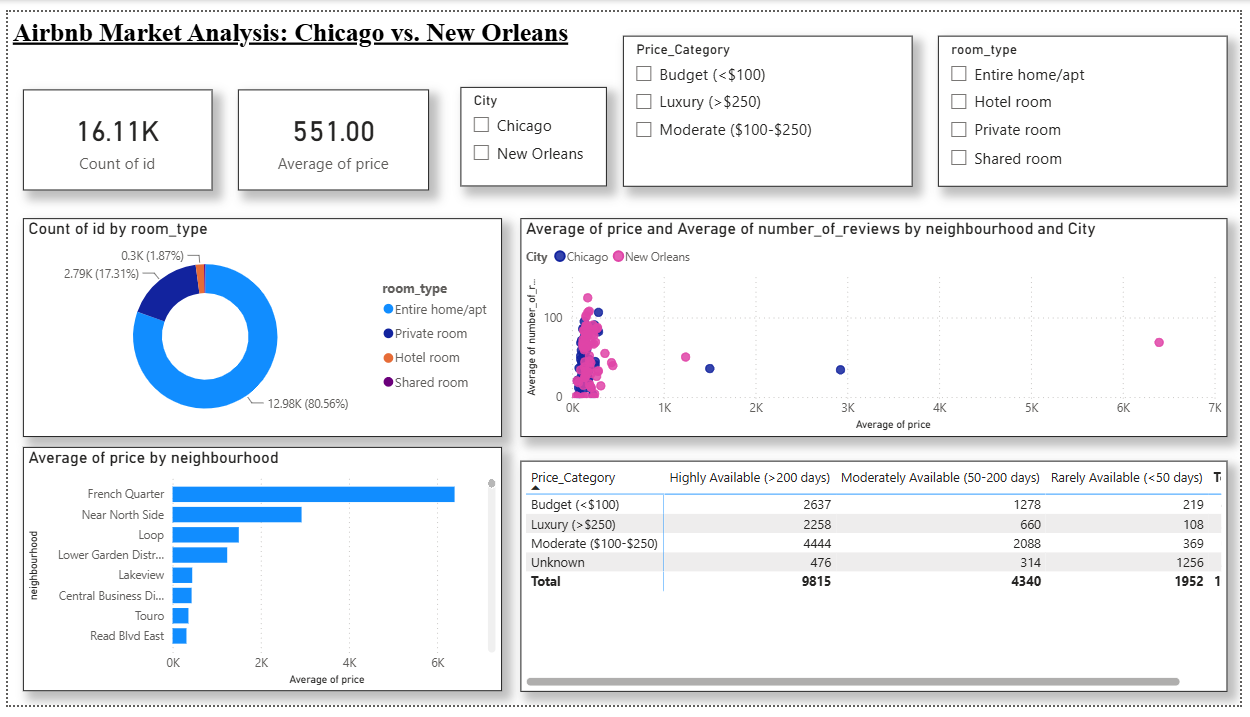

### 📊 Executive Insight: Combined Market Scale
The global view represents the consolidated market footprint of both cities combined. It establishes baseline metrics for comparative analysis.

* **Scale & Inventory:** The combined dataset features **16,107 listings** with a consolidated average price of **$551.00**.
* **Room Type Share:** **Entire home/apartment** listings heavily dominate the inventory at **80.56%** (12.98K listings), indicating that travelers to both markets prioritize complete accommodations over shared spaces.
* **Availability & Pricing Matrix:** Cross-tabulating price categories against availability shows that **Highly Available listings (>200 days/year)** constitute the majority of active inventory (**9,815 listings**), signaling a highly professionalized host base in both cities.

## 2. Chicago Market Analysis

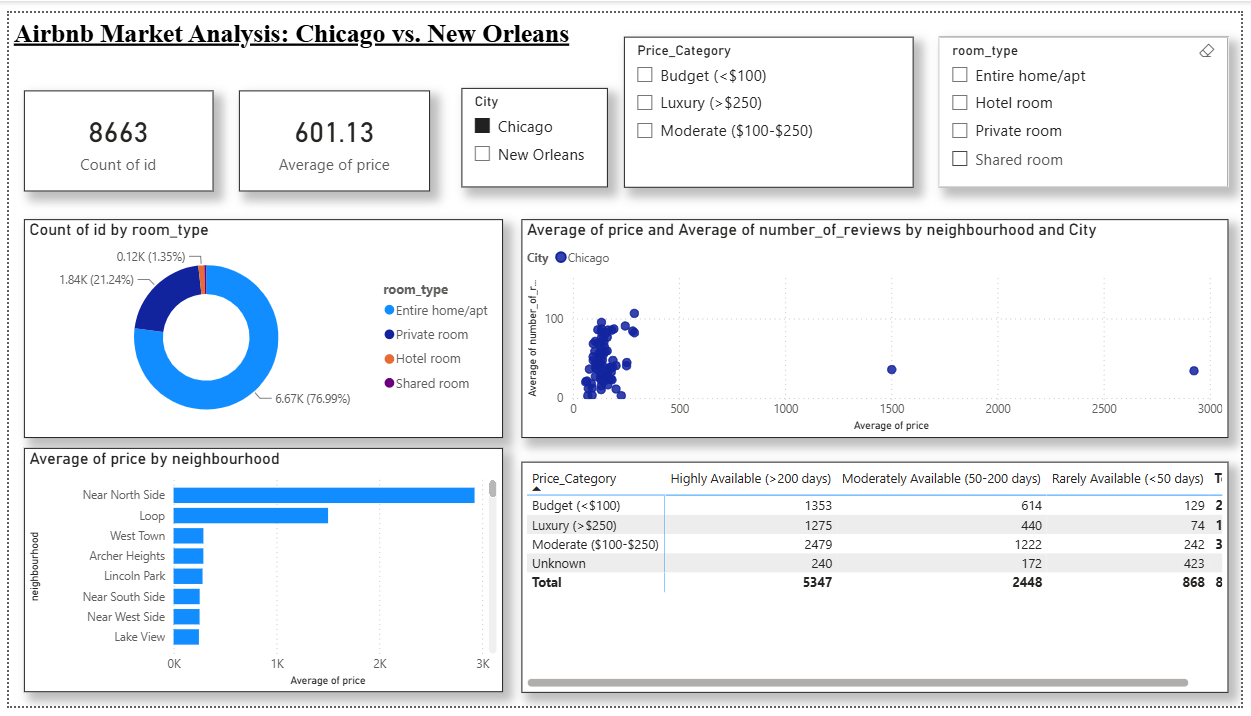

### 🏙️ Chicago Market Focus: Larger Scale, Higher Price Ceiling
Filtering the dashboard for **Chicago** isolates the Midwestern hub's listings to analyze localized supply dynamics and geographic density.

* **Inventory Scale:** Chicago holds the larger share of listings with **8,640 listings** (53.6% of the combined market).
* **Pricing Dynamics:** The average price in Chicago sits at **$602.17**. This is driven by high-value residential areas and business travel demand.
* **Neighborhood Centers:** The average price bar chart identifies **Near North Side** and **Loop** as the premium pricing neighborhoods, reflecting the concentration of luxury high-rises and business-travel centric lodging.
* **Diverse Room Selection:** Chicago has a significantly higher share of **Private Room** listings (**21.26%** vs New Orleans' **12.76%**), accommodating budget-conscious travelers and students.

## 3. New Orleans Market Analysis

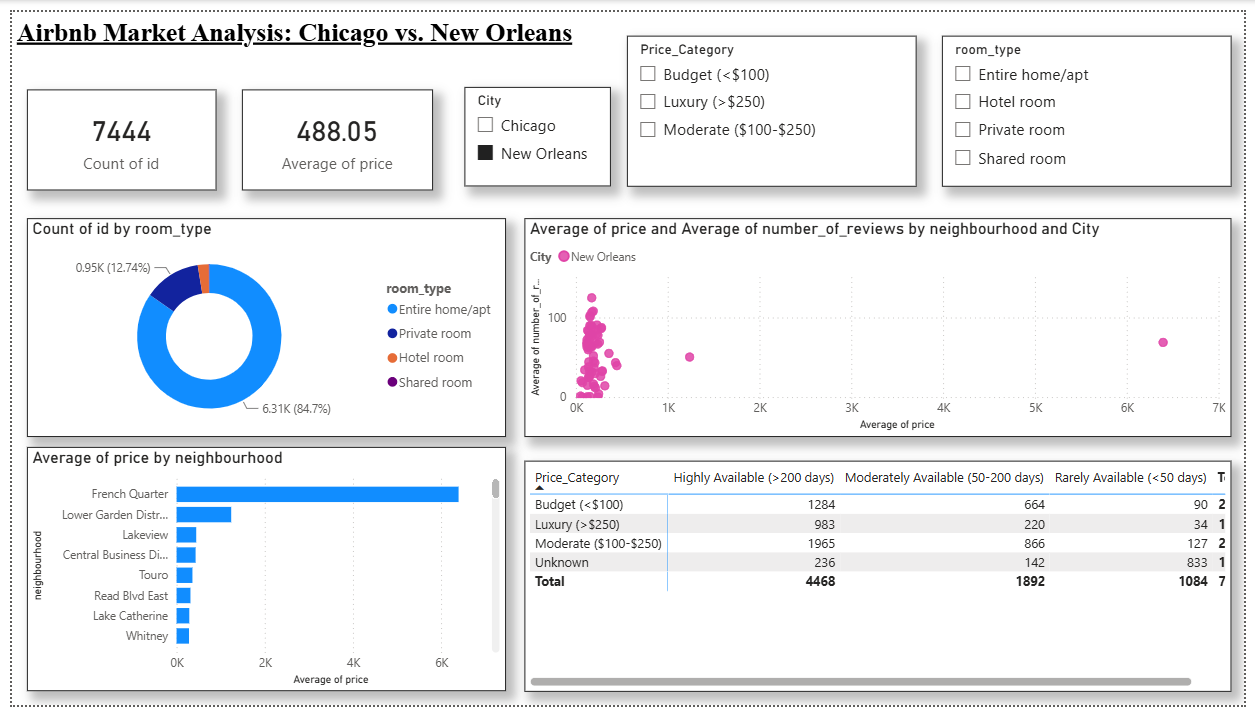

### 🎷 New Orleans Market Focus: Tourism-Driven, High Density
Filtering for **New Orleans** reveals a unique, travel-centric market structure heavily anchored by historical tourism districts.

* **Inventory Scale:** New Orleans accounts for **7,416 listings** (46.4% of the combined market).
* **Average Price:** The average listing price is **$488.92**, which is lower than Chicago's average, but is heavily skewed by premium vacation rentals in tourism corridors.
* **Extreme Geographic Concentration:** The neighborhood pricing chart shows that the **French Quarter** has an extraordinary average price point (exceeding $6,000 for outliers / luxury listings), creating a massive pricing anchor for the entire city.
* **Entire Home Preference:** Vacation rentals dominate heavily with **84.67%** of listings categorized as **Entire home/apt**, demonstrating that tourists to New Orleans prefer independent units.

## 4. Key Segment Focus: Budget Listings & Customer Engagement

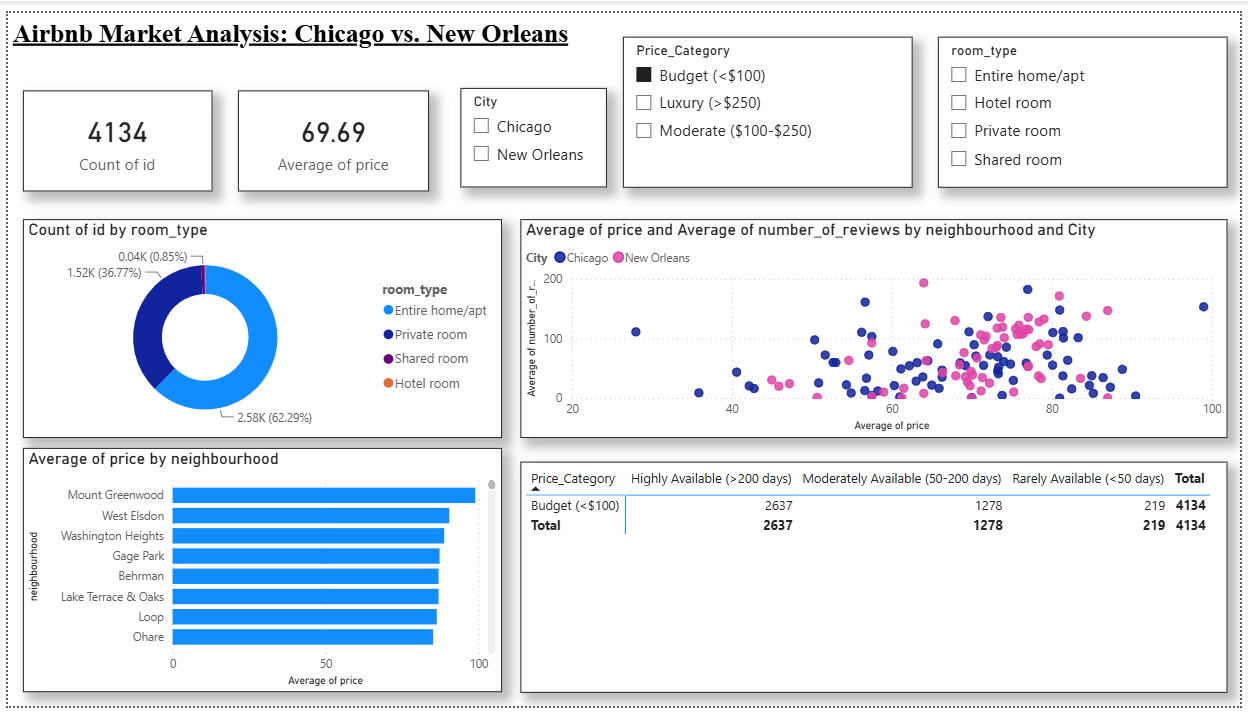

### 💰 Customer Segment Insight: The Budget Driver
Isolating listings in the **Budget (<$100)** price category highlights the listings that drive the highest volume of consumer activity.

* **Volume Leader:** The Budget segment contains **4,134 listings** across both cities, maintaining an average price of **$69.69**.
* **Review Density:** The **Price vs. Number of Reviews scatter plot** shows that the highest concentration of reviews (representing booking frequency and host-guest interaction) is clustered under $100. This confirms that value-priced listings are the true engines of volume and transaction velocity on the platform.
* **Neighborhood Dispersion:** Unlike luxury listings which cluster heavily in the French Quarter or Downtown Chicago, budget listings are widely distributed across diverse local neighborhoods, dispersing tourism dollars deeper into local communities.

## 🎯 Summary & Actionable Recommendations
Based on the comparative analysis of the Chicago and New Orleans markets, the following strategic guidelines are recommended:

1. **New Orleans Investment:** Focus exclusively on **Entire home/apartment** units near historical or cultural tourism zones (like Mid-City or areas surrounding the French Quarter) to capitalize on high tourist demand and premium pricing.
2. **Chicago Investment:** Chicago offers opportunities for both corporate Entire Home rentals in business hubs and **Private Room** rentals in residential/university areas. Diversifying across neighborhoods can hedge against regulatory and seasonal demand swings.
3. **Pricing Optimization:** Listings positioned in the **Budget-to-Moderate** range ($80 - $150) capture the highest volume of reviews and customer engagement. Hosts should aim for this sweet spot to maximize occupancy rates and organic search visibility on the platform.